In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import date, timedelta
from scipy.signal import argrelmin
import matplotlib.pyplot as plt
import duckdb
import pyarrow

sns.set_theme(style='whitegrid', context='notebook')
pl.Config.set_tbl_rows(20)

DATA = Path('data/user_actions_3_months')
PRODUCTS = Path('data/product_information')

WEEK_START = date(2024, 3, 4)
WEEK_END   = date(2024, 4, 30)#весь промежуток, который мы исследуем


# Предобработка и построение гистограммы

In [2]:
LOG_BINS = np.linspace(np.log10(1/60), np.log10(60 * 24 * 7), 120)

con = duckdb.connect()
con.execute("SET memory_limit='10GB'; SET threads=4;")# при запуске на своем пк обдумайте сколько памяти и потоков аллоцировать

result = con.execute(f"""
    WITH gaps AS (
        SELECT
            user_id,
            DATEDIFF('second',
                LAG(timestamp) OVER (PARTITION BY user_id ORDER BY timestamp),
                timestamp
            ) / 60.0 AS gap_min
        FROM read_parquet('{DATA}/**/*.parquet', hive_partitioning = true)
    )
    SELECT
        floor(log10(gap_min) * 40) / 40 AS log10_gap_bin,
        count(*) AS n
    FROM gaps
    WHERE gap_min > 0
    GROUP BY 1
    ORDER BY 1
""").pl()

print('total gaps:',result["n"].sum())


total gaps: 222669021


In [3]:
log_vals = result['log10_gap_bin'].to_numpy()
counts = result['n'].to_numpy()

bin_index = np.searchsorted(LOG_BINS, log_vals, side='right') - 1
valid = (bin_index >= 0) & (bin_index < len(LOG_BINS) - 1)
hist_counts = np.zeros(len(LOG_BINS) - 1, dtype=np.int64)
np.add.at(hist_counts, bin_index[valid], counts[valid])
total_gaps = int(result['n'].sum())

In [ ]:
bin_centres = 10 ** ((LOG_BINS[:-1] + LOG_BINS[1:]) / 2) 
log_centres = (LOG_BINS[:-1] + LOG_BINS[1:]) / 2


[266.  35.  62.]


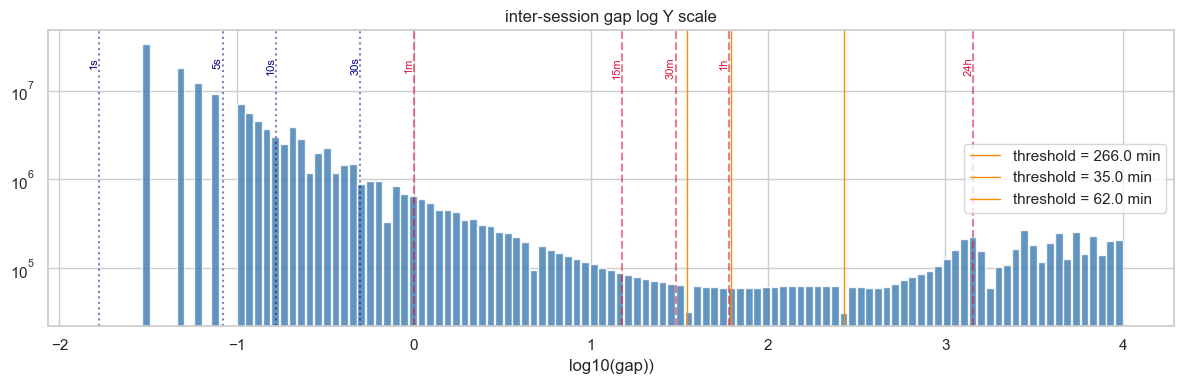

plot saved: docs/gap_histogram.png


In [ ]:
valley = argrelmin(hist_counts, order=4)[0].tolist()


best_idx = sorted(valley, key=lambda i: hist_counts[i])[0:3]
threshold_min = bin_centres[best_idx].round()

print(threshold_min)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(log_centres, hist_counts, width=(LOG_BINS[1]-LOG_BINS[0])*0.9,
       color='steelblue', alpha=0.85)
ax.set_yscale('log')

for t_sec, label in [(1,'1s'),(5,'5s'),(10,'10s'),(30,'30s')]:
    ax.axvline(np.log10(t_sec/60), ls=':', color='navy', alpha=0.5)
    ax.text(np.log10(t_sec/60), ax.get_ylim()[1]*0.5, label,
            rotation=90, va='top', ha='right', color='navy', fontsize=8)

for t_min, label in [(1,'1m'),(15,'15m'),(30,'30m'),(60,'1h'),(60*24,'24h')]:
    ax.axvline(np.log10(t_min), ls='--', color='crimson', alpha=0.55)
    ax.text(np.log10(t_min), ax.get_ylim()[1]*0.5, label,
            rotation=90, va='top', ha='right', color='crimson', fontsize=8)
for the_min in threshold_min:
    ax.axvline(np.log10(the_min), ls='-', color='darkorange', lw=1,
           label=f'threshold = {the_min} min')
ax.legend()
ax.set_xlabel('log10(gap))')
ax.set_title('inter-session gap log Y scale')
plt.tight_layout()

docs_dir = Path('docs')
fig.savefig(docs_dir / 'gap.png', dpi=300)
plt.show()